In [187]:
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import transforms
from matplotlib import colormaps
import pandas as pd

Principle Component Analysis

In [69]:
def PCA(X):
    """PCA Run principal component analysis on the dataset X 
    computes eigenvectors of the covariance matrix of X
    Returns the eigenvectors U, the eigenvalues (on diagonal) in S"""
    m,n = X.shape

    U = np.zeros(n)
    S = np.zeros(n)

    cov_x = (1/m)*np.transpose(X)@X
    U,S,V = np.linalg.svd(cov_x)
    return U,S,V

def get_max_variation_vector(U,S):
    """ Returns seq. of vectors [X1,X2,...] """
    return U @ np.diag(S)

def feature_normalize(X):
    mu = np.mean(X,axis=0);
    sigma = np.std(X,axis=0)
    X_norm = (X-mu)/sigma 
    return X_norm,mu,sigma

In [70]:
## ================== Part 1: Load Example Dataset  ===================
print('Visualizing example dataset for PCA.\n');
data = sio.loadmat('ex7data1.mat')
X = data['X']
m,n = X.shape
m,n 

Visualizing example dataset for PCA.



(50, 2)

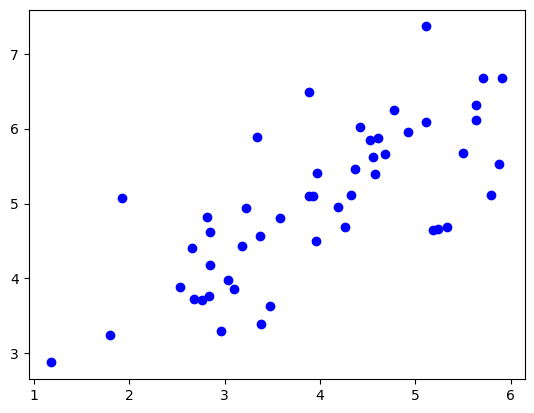

In [71]:
plt.scatter(X[:, 0], X[:, 1], marker='o',color='blue')


Running PCA on example dataset.



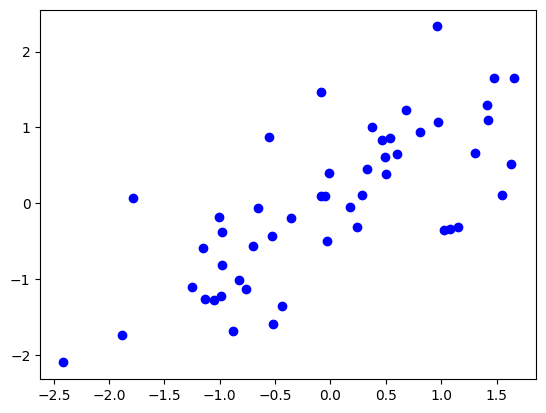

In [72]:
## =============== Part 2: Principal Component Analysis ===============
print('\nRunning PCA on example dataset.\n');

## normalize X
[X_norm, mu, sigma] = feature_normalize(X)
U,S,_ = PCA(X_norm)
plt.scatter(X_norm[:, 0], X_norm[:, 1], marker='o',color='b');

In [73]:
# Draw the eigenvectors centered at mean of data. 
# These lines show the directions of maximum variations in the dataset.
mv_vec = get_max_variation_vector(U,S).T
mu_mat = np.ones((n,1))*mu

# start_points = mu_mat
# end_points = mu_mat + mv_vec
start_points = np.zeros_like(mu_mat)
end_points = np.zeros_like(mu_mat) + mv_vec

start_points,end_points
print('Top eigenvector: %f %f' % (U[0,0],U[1,0]))

Top eigenvector: -0.707107 -0.707107


In [74]:
X_start = start_points[:,0]
Y_start = start_points[:,1]
X_end = end_points[:,0]
Y_end = end_points[:,1]
X_start,Y_start

(array([0., 0.]), array([0., 0.]))

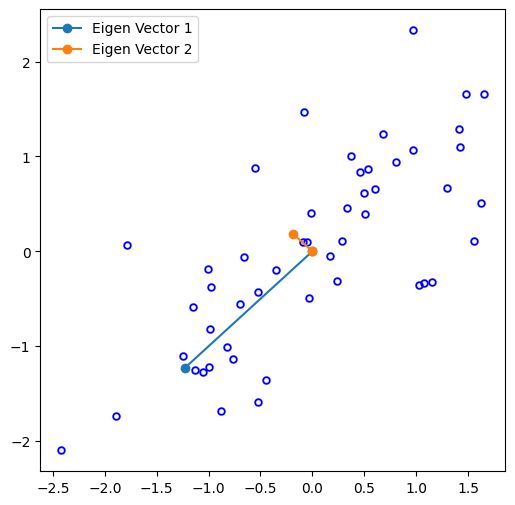

In [75]:
norm = True
# Plot each line
plt.figure(figsize=(6, 6))
for i in range(len(X_start)):
    plt.plot([X_start[i], X_end[i]], [Y_start[i], Y_end[i]], marker='o', label=f'Eigen Vector {i+1}')


if norm:
    plt.scatter(X_norm[:, 0], X_norm[:, 1], marker='$\\circ$',color='blue',linewidths=0.1)
else:
    plt.scatter(X[:, 0], X[:, 1], marker='$\\circ$',color='blue',linewidths=0.1)
plt.legend()

## =================== Part 3: Dimension Reduction ===================
You should now implement the projection step to map the data onto the first k eigenvectors.<br>
The code will then plot the data in this reduced dimensional space. <br>
This will show you what the data looks like when using only the corresponding eigenvectors to reconstruct it.

In [76]:
def project_data(X, U, K):
    """ Computes the reduced data representation when projecting only on to the top k eigenvectors
        Computes the projection of the normalized inputs X into the reduced dimensional space spanned
        by the first K columns of U.
    """
    Z = np.zeros((X.shape[0], K))
    Z[:,:] = X @ U[:,0:K]
    return Z

def recover_data(Z,U,K):
    X_rec = np.zeros((Z.shape[0],U.shape[0]))
    X_rec[:,:] = Z @ U[:, 0:K].T
    return X_rec

In [77]:
# Project the data onto K = 1 dimension
K = 1
X_compressed = project_data(X_norm,U,K)
X_compressed[0]

array([1.49631261])

In [78]:
# Recovery of the projected data (approximation) 
X_recovered  = recover_data(X_compressed, U, K);
X_recovered[0]

array([-1.05805279, -1.05805279])

In [79]:
U[:,0:n]

array([[-0.70710678, -0.70710678],
       [-0.70710678,  0.70710678]])

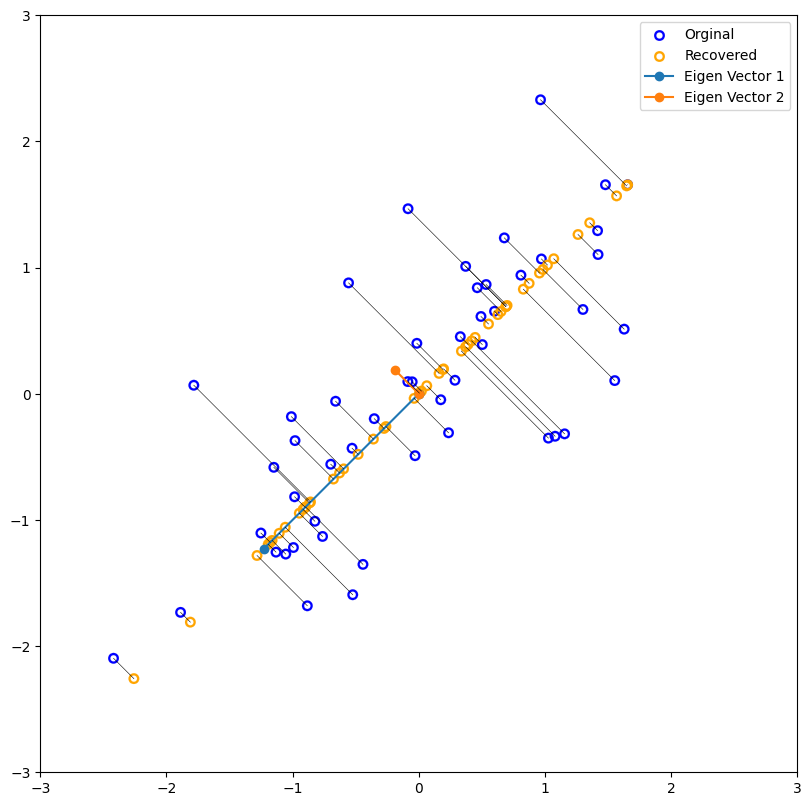

In [80]:
fig,ax = plt.subplots(figsize=(8, 8),layout='constrained')
ax.scatter(X_norm[:, 0], X_norm[:, 1], marker='$\\circ$',color='blue',linewidths=0.1,label="Orginal",s=60*np.ones((m,1)))
ax.scatter(X_recovered[:, 0], X_recovered[:, 1], marker='$\\circ$',color='orange',linewidths=0.1,label="Recovered",s=60*np.ones((m,1)))
for i in range(len(X_start)):
    ax.plot([X_start[i], X_end[i]], [Y_start[i], Y_end[i]], marker='o', label=f'Eigen Vector {i+1}')

for i in range(m):
    ax.plot([X_norm[i,0], X_recovered[i,0]], [X_norm[i,1], X_recovered[i,1]],c='black',linewidth=.4)
ax.set_xlim(-3,3)
ax.set_ylim(-3,3)
ax.legend()
ax.set_aspect('equal')

### =============== PCA on Face Data: Eigenfaces =============

In [125]:
def display_data(X,width=None,pad=1,title=''):
    if not width:
        width = round(np.sqrt(X.shape[1]))
    m,n = X.shape
    height  = int(n/width)
    n_rows = int(np.floor(np.sqrt(m)))
    n_cols = int(np.ceil(m/n_rows))
    display = np.zeros((pad+(height+pad)*n_rows,pad+(width+pad)*n_cols))
    idx = 0
    for i in range(n_rows):
        for j in range(n_cols):
            if idx>=m:
                break
            display[pad+(height+pad)*i:pad+(height+pad)*i+height,pad+(width+pad)*j:pad+(width+pad)*j+width]=X[idx].reshape(width,height)
            idx+=1
        if idx>=m:
            break
    fig = plt.figure()
    ax = fig.add_subplot(111)
    # tr = transforms.Affine2D().rotate_deg(90)
    ax.imshow(display,cmap='gray')
    ax.set_title(title)


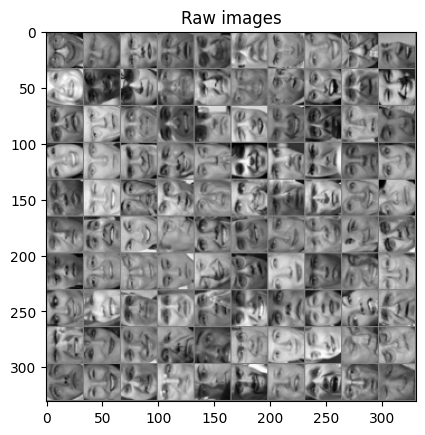

In [126]:
# Loading and Visualizing Face Data
data = sio.loadmat('ex7faces.mat')
X = data['X']
display_data(X[:100,:],32,title='Raw images')

In [127]:
# Run PCA and visualize the eigenvectors which are in this case eigenfaces
# Before running PCA, it is important to first normalize X by subtracting the mean value from each feature
[X_norm, mu, sigma] = feature_normalize(X)

In [128]:
# Run PCA
[U, S,_] = PCA(X_norm)

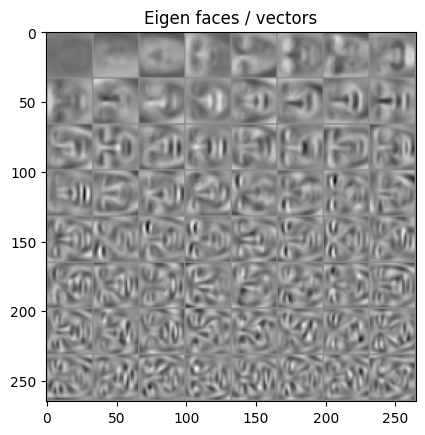

In [129]:
display_data(U[:,:64].T,title='Eigen faces / vectors')

In [130]:
### ============= Dimension Reduction for Faces =================
# Project images to the eigen space using the top K eigenvectors 
K = 100
Z = project_data(X_norm, U, K)

In [131]:
X_rec  = recover_data(Z, U, K)

In [132]:
X_rec.shape

(5000, 1024)

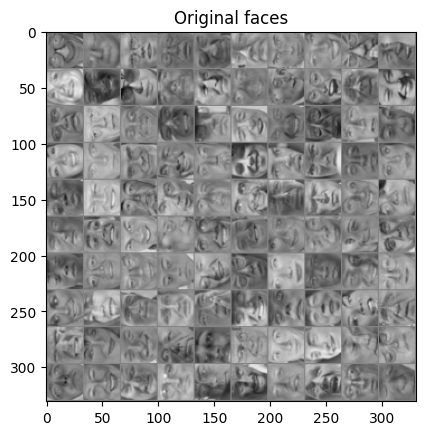

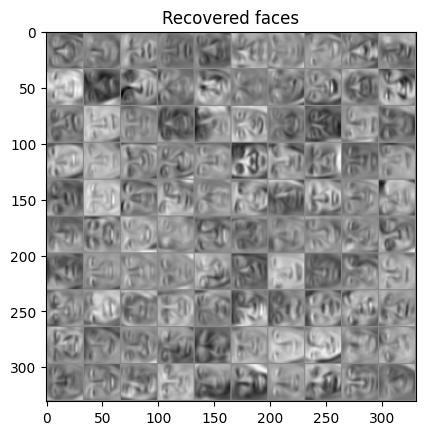

In [133]:
display_data(X_norm[:100,:],title='Original faces')
display_data(X_rec[:100,:],title='Recovered faces')

One useful application of PCA is to use it to visualize high-dimensional data. 
We first visualize an image in 3D, and then apply PCA to obtain a visualization in 2D.

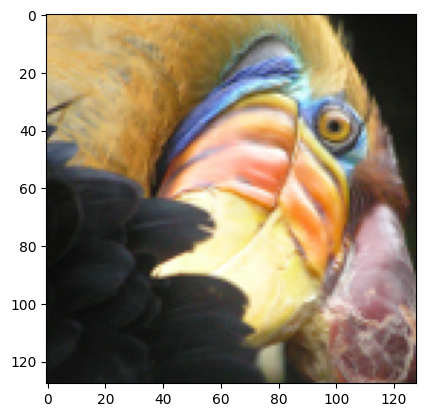

In [138]:
A = plt.imread('bird_small.png')
A.shape
plt.imshow(A)

In [153]:
import sys
sys.path.append(r"C:\Chethan\Technologies\Artificial Inteligence\Machine Learning\Unsupervised Learning\clustering\python")
from k_means import kmeans,kMeans_init_centroids

In [308]:
# Pre-process image
m,n,_ = A.shape
X = A.reshape(m*n, 3)
K = 16
max_iters = 10
initial_centroids = kMeans_init_centroids(X, K);
[centroids, idx] = kmeans(X, initial_centroids, max_iters)

K-Means iteration 1/10...

K-Means iteration 2/10...

K-Means iteration 3/10...

K-Means iteration 4/10...

K-Means iteration 5/10...

K-Means iteration 6/10...

K-Means iteration 7/10...

K-Means iteration 8/10...

K-Means iteration 9/10...



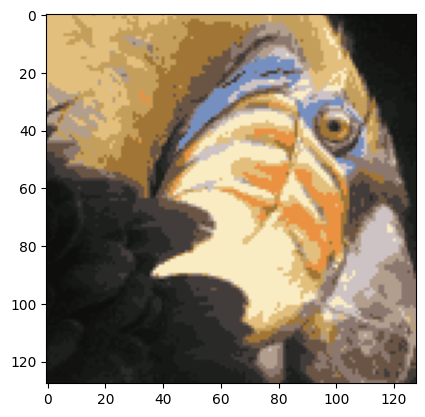

In [368]:
X_recovered = centroids[idx.astype(np.uint),:]
# Reshape the recovered image into proper dimensions
X_recovered_img = X_recovered.reshape(int(np.sqrt(X_recovered.shape[0])),int(np.sqrt(X_recovered.shape[0])),3)
plt.imshow(X_recovered_img)

In [315]:
# Sample 1000 random indexes
import random
m,n = X.shape
n_samples = 100

li = random.sample(range(m), n_samples)
X_samples = X[li]
idx_sample = idx[li].flatten().astype(np.uint8)

In [332]:
unique_groups = np.unique(idx_sample)
colors = plt.cm.jet(np.linspace(0,1,K))
unique_groups.shape,X_samples.shape,colors.shape

((16,), (100, 3), (16, 4))

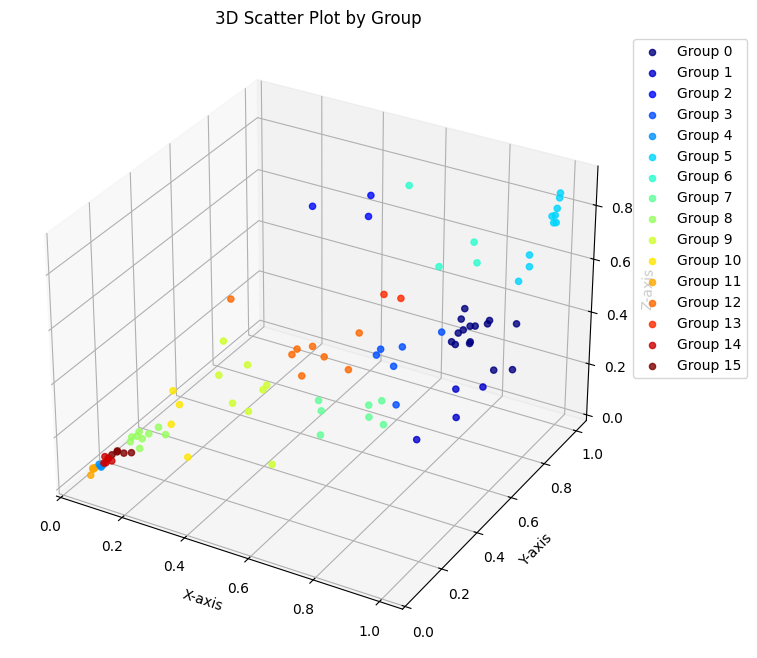

In [355]:
# Create 3D scatter plot
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot each group with a unique color
for i, group in enumerate(unique_groups):
    mask = idx_sample == group
    ax.scatter(X_samples[mask, 0], X_samples[mask, 1], X_samples[mask, 2], color=colors[i], label=f'Group {group}', alpha=0.8)

ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.set_zlabel('Z-axis')
ax.set_title('3D Scatter Plot by Group')
ax.legend(bbox_to_anchor =(1,1),loc='upper left')
plt.show()

In [ ]:
# Use PCA to project this cloud to 2D for visualization

In [342]:
[X_norm, mu, sigma] = feature_normalize(X)

#PCA and project the data to 2D
[U, S,_] = PCA(X_norm)
Z = project_data(X_norm, U, 2)

In [344]:
Z_samples = Z[li]

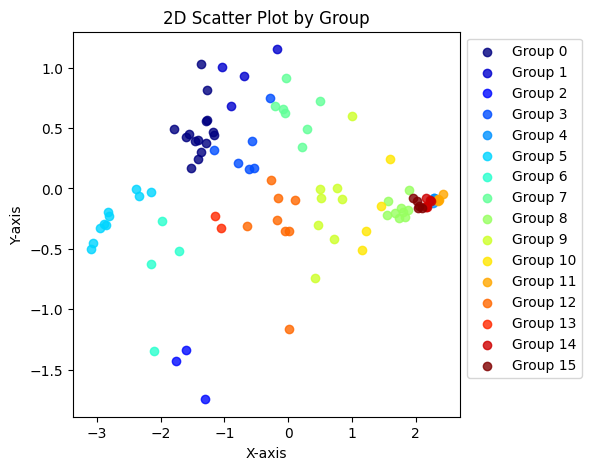

In [354]:
# Create 3D scatter plot
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111)

# Plot each group with a unique color
for i, group in enumerate(unique_groups):
    mask = idx_sample == group
    ax.scatter(Z_samples[mask, 0], Z_samples[mask, 1], color=colors[i], label=f'Group {group}', alpha=0.8)

ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.set_title('2D Scatter Plot by Group')
ax.legend(bbox_to_anchor =(1,1),loc='upper left')
plt.show()

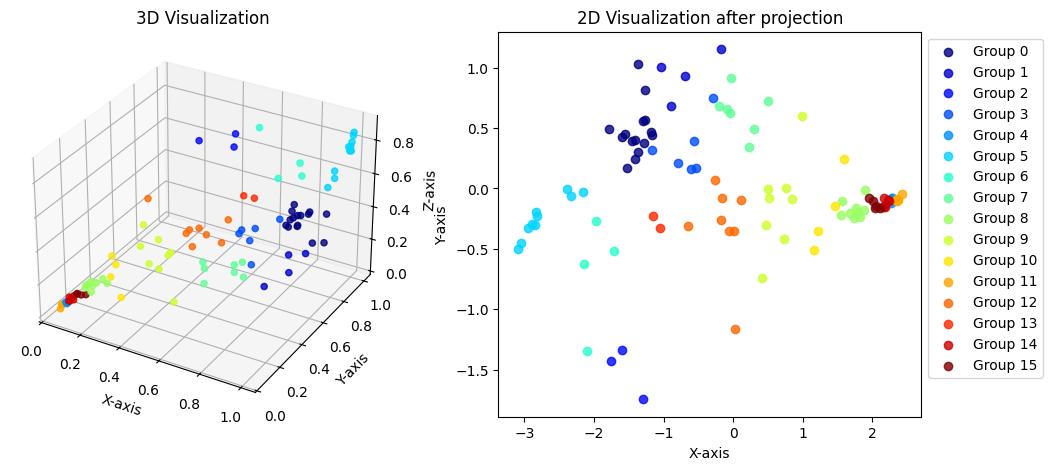

In [360]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

# Generate data for 2D scatter plot
x_2d = np.linspace(-5, 5, 100)
y_2d = np.sin(x_2d) + 0.1 * np.random.randn(100)  # Adding some noise

# Generate data for 3D scatter plot
x_3d = np.random.uniform(-5, 5, 100)
y_3d = np.random.uniform(-5, 5, 100)
z_3d = np.sin(np.sqrt(x_3d**2 + y_3d**2)) + 0.1 * np.random.randn(100)  # Adding some noise

# Create figure and subplots
fig = plt.figure(figsize=(12, 5))

# 2D Scatter Plot
ax1 = fig.add_subplot(1, 2, 1,projection='3d')
# Plot each group with a unique color
for i, group in enumerate(unique_groups):
    mask = idx_sample == group
    ax1.scatter(X_samples[mask, 0], X_samples[mask, 1], X_samples[mask, 2], color=colors[i], label=f'Group {group}', alpha=0.8)
   
ax1.set_title('3D Visualization')
ax1.set_xlabel('X-axis')
ax1.set_ylabel('Y-axis')
ax1.set_zlabel('Z-axis')
ax1.grid()

# 3D Scatter Plot
ax2 = fig.add_subplot(1, 2, 2)
# Plot each group with a unique color
for i, group in enumerate(unique_groups):
    mask = idx_sample == group
    ax2.scatter(Z_samples[mask, 0], Z_samples[mask, 1], color=colors[i], label=f'Group {group}', alpha=0.8)
   
ax2.set_xlabel('X-axis')
ax2.set_ylabel('Y-axis')
ax2.set_title('2D Visualization after projection')
ax2.legend(bbox_to_anchor =(1,1),loc='upper left')

plt.show()
